In [ ]:
import pandas as pd
train = pd.read_csv('/content/drive/MyDrive/deep_project-co5420-human-activity-recognition/train.csv')
print("Shape:", train.shape)

Shape: (7352, 563)


In [ ]:
# See the activity labels and distribution
print("Activities:\n", train['Activity'].value_counts())
print("\nColumn names (first 5):", train.columns[:5].tolist())
print("\nMissing values:", train.isnull().sum().sum())
print("\nDuplicates:", train.duplicated().sum())

Activities:
 Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

Column names (first 5): ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y']

Missing values: 0

Duplicates: 0


In [ ]:
# Separate features, labels, and subject
X = train.drop(columns=['Activity', 'subject'])
y = train['Activity']

print("Features shape:", X.shape)
print("Labels shape:", y.shape)
print("\nUnique activities:", y.unique())

Features shape: (7352, 561)
Labels shape: (7352,)

Unique activities: ['STANDING' 'SITTING' 'LAYING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


In [ ]:
# Train/val split + normalization
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Split FIRST, then scale
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Fit scaler on training data ONLY
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Train size:", X_train_scaled.shape)
print("Val size:", X_val_scaled.shape)
print("\nScaling done!")
print("Mean of first feature (should be ~0):",
       X_train_scaled[:,0].mean().round(4))

Train size: (5881, 561)
Val size: (1471, 561)

Scaling done!
Mean of first feature (should be ~0): 0.0


Macro F1 Score: 0.9374

Full Report:
                     precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       282
           SITTING       0.90      0.91      0.90       257
          STANDING       0.91      0.90      0.91       275
           WALKING       0.93      0.96      0.94       245
WALKING_DOWNSTAIRS       0.93      0.95      0.94       197
  WALKING_UPSTAIRS       0.96      0.91      0.93       215

          accuracy                           0.94      1471
         macro avg       0.94      0.94      0.94      1471
      weighted avg       0.94      0.94      0.94      1471



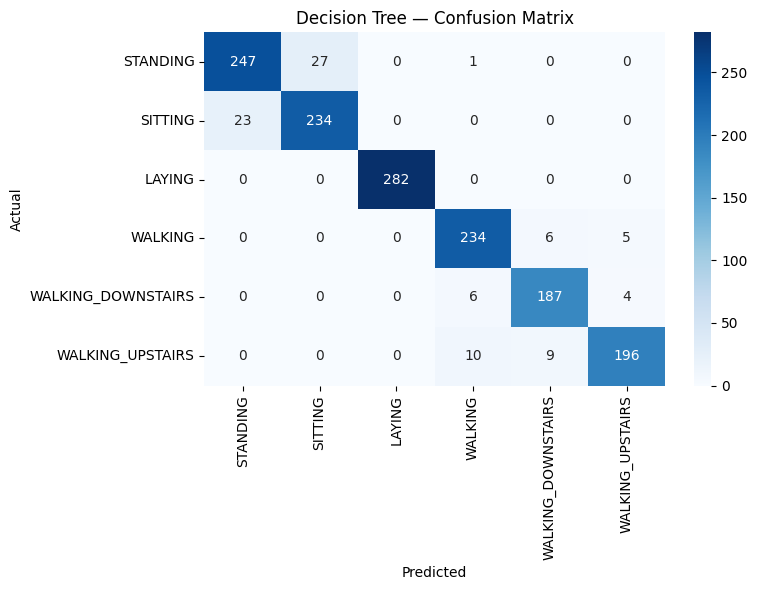

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)

# Predict on validation set
y_pred = dt.predict(X_val_scaled)

# Evaluate
print("Macro F1 Score:", round(f1_score(y_val, y_pred, average='macro'), 4))
print("\nFull Report:\n", classification_report(y_val, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred, labels=y.unique())
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=y.unique(),
            yticklabels=y.unique(),
            cmap='Blues')
plt.title('Decision Tree — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
# Hyperparameter tuning  ## just
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train_scaled, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV Macro F1:", round(grid.best_score_, 4))

# Evaluate tuned model on validation set
best_dt = grid.best_estimator_
y_pred_tuned = best_dt.predict(X_val_scaled)
print("Tuned Val Macro F1:", round(f1_score(y_val, y_pred_tuned, average='macro'), 4))

NameError: name 'DecisionTreeClassifier' is not defined

In [ ]:
"""import joblib

# Save directly to Google Drive
joblib.dump(scaler, '/content/drive/MyDrive/deep_project-co5420-human-activity-recognition/scaler.pkl')
joblib.dump(best_dt, '/content/drive/MyDrive/deep_project-co5420-human-activity-recognition/best_decision_tree.pkl')

print("Saved to Google Drive successfully!")
"""

In [ ]:
"""
import pandas as pd
import numpy as np

# Save scaled arrays as CSV for teammates
pd.DataFrame(X_train_scaled).to_csv('/content/drive/MyDrive/deep_project-co5420-human-activity-recognition/X_train_scaled.csv', index=False)
pd.DataFrame(X_val_scaled).to_csv('/content/drive/MyDrive/deep_project-co5420-human-activity-recognition/X_val_scaled.csv', index=False)
y_train.to_csv('/content/drive/MyDrive/deep_project-co5420-human-activity-recognition/y_train.csv', index=False)
y_val.to_csv('/content/drive/MyDrive/deep_project-co5420-human-activity-recognition/y_val.csv', index=False)

print("All processed data saved to Drive!")
"""

In [ ]:
## Sensor Ablation Analysis

# Get all feature names
feature_names = X.columns.tolist()

# Filter accelerometer and gyroscope features
acc_features = [f for f in feature_names if 'Acc' in f]
gyro_features = [f for f in feature_names if 'Gyro' in f]

print("Total features:", len(feature_names))
print("Accelerometer features:", len(acc_features))
print("Gyroscope features:", len(gyro_features))

Total features: 561
Accelerometer features: 345
Gyroscope features: 213


In [ ]:
## ablation experiment

# Accelerometer only
X_train_acc = X_train[acc_features]
X_val_acc = X_val[acc_features]

# Gyroscope only
X_train_gyro = X_train[gyro_features]
X_val_gyro = X_val[gyro_features]

# Scale each separately
scaler_acc = StandardScaler()
X_train_acc_scaled = scaler_acc.fit_transform(X_train_acc)
X_val_acc_scaled = scaler_acc.transform(X_val_acc)

scaler_gyro = StandardScaler()
X_train_gyro_scaled = scaler_gyro.fit_transform(X_train_gyro)
X_val_gyro_scaled = scaler_gyro.transform(X_val_gyro)

# Train Decision Tree on accelerometer only
dt_acc = DecisionTreeClassifier(criterion='entropy', max_depth=10,
                                 min_samples_split=5, random_state=42)
dt_acc.fit(X_train_acc_scaled, y_train)
y_pred_acc = dt_acc.predict(X_val_acc_scaled)
f1_acc = round(f1_score(y_val, y_pred_acc, average='macro'), 4)

# Train Decision Tree on gyroscope only
dt_gyro = DecisionTreeClassifier(criterion='entropy', max_depth=10,
                                  min_samples_split=5, random_state=42)
dt_gyro.fit(X_train_gyro_scaled, y_train)
y_pred_gyro = dt_gyro.predict(X_val_gyro_scaled)
f1_gyro = round(f1_score(y_val, y_pred_gyro, average='macro'), 4)

# Print comparison
print("=" * 45)
print("SENSOR ABLATION ANALYSIS — Decision Tree")
print("=" * 45)
print(f"Accelerometer only ({len(acc_features)} features): {f1_acc}")
print(f"Gyroscope only    ({len(gyro_features)} features): {f1_gyro}")
print(f"Combined          (561 features)        : 0.9399")
print("=" * 45)

SENSOR ABLATION ANALYSIS — Decision Tree
Accelerometer only (345 features): 0.9448
Gyroscope only    (213 features): 0.7672
Combined          (561 features)        : 0.9399


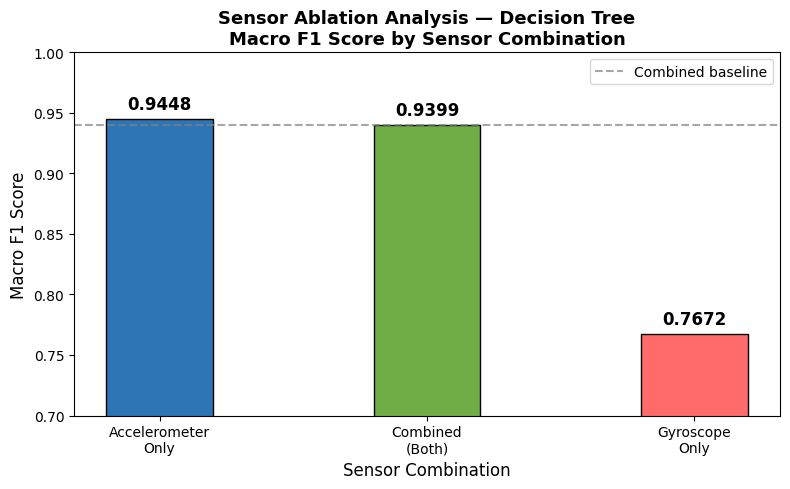

Chart saved to Drive!


In [ ]:
import matplotlib.pyplot as plt

sensors = ['Accelerometer\nOnly', 'Combined\n(Both)', 'Gyroscope\nOnly']
scores = [0.9448, 0.9399, 0.7672]
colors = ['#2E75B6', '#70AD47', '#FF6B6B']

plt.figure(figsize=(8, 5))
bars = plt.bar(sensors, scores, color=colors, width=0.4, edgecolor='black')

# Add score labels on top of bars
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             str(score), ha='center', va='bottom',
             fontweight='bold', fontsize=12)

plt.ylim(0.7, 1.0)
plt.title('Sensor Ablation Analysis — Decision Tree\nMacro F1 Score by Sensor Combination',
          fontsize=13, fontweight='bold')
plt.ylabel('Macro F1 Score', fontsize=12)
plt.xlabel('Sensor Combination', fontsize=12)
plt.axhline(y=0.9399, color='gray', linestyle='--', alpha=0.7, label='Combined baseline')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/deep_project-co5420-human-activity-recognition/sensor_ablation_chart.png', dpi=150)
plt.show()

print("Chart saved to Drive!")

In [ ]:
import pandas as pd
import joblib

# Step 1 — Load test.csv
test = pd.read_csv('/content/drive/MyDrive/deep_project-co5420-human-activity-recognition/test.csv')
print("Test shape:", test.shape)

# Step 2 — Separate id and features
test_ids = test['id']
X_test = test.drop(columns=['id', 'subject'])

# Step 3 — Load your saved scaler and model
scaler = joblib.load('/content/drive/MyDrive/deep_project-co5420-human-activity-recognition/scaler.pkl')
best_dt = joblib.load('/content/drive/MyDrive/deep_project-co5420-human-activity-recognition/best_decision_tree.pkl')

# Step 4 — Scale test features
X_test_scaled = scaler.transform(X_test)

# Step 5 — Predict
y_pred = best_dt.predict(X_test_scaled)

# Step 6 — Create submission file
submission = pd.DataFrame({
    'id': test_ids,
    'Activity': y_pred
})

# Step 7 — Check format
print(submission.head(10))
print("Shape:", submission.shape)
print("Unique activities:", submission['Activity'].unique())

# Step 8 — Save to Drive
submission.to_csv(
    '/content/drive/MyDrive/deep_project-co5420-human-activity-recognition/submission_decision_tree.csv',
    index=False
)
print("Saved!")

Test shape: (2947, 563)
   id  Activity
0   1   SITTING
1   2  STANDING
2   3  STANDING
3   4  STANDING
4   5  STANDING
5   6  STANDING
6   7  STANDING
7   8  STANDING
8   9  STANDING
9  10  STANDING
Shape: (2947, 2)
Unique activities: ['SITTING' 'STANDING' 'LAYING' 'WALKING' 'WALKING_UPSTAIRS'
 'WALKING_DOWNSTAIRS']
Saved!
